# Excess Hospital Readmissions: What Explains the Variation CMS Can't?

**Question.** Medicare's Hospital Readmissions Reduction Program (HRRP) publishes an *Excess Readmission Ratio* (ERR) for every eligible hospital and condition. The ratio is already risk-adjusted for patient case mix — age, comorbidities, and clinical severity are divided out. An ERR above 1.0 means a hospital readmitted **more patients than CMS predicted for patients like theirs**.

So the interesting question is not "which patients get readmitted" — CMS has already conditioned on that. It is:

> **After patient case mix is accounted for, do a hospital's structural characteristics — who owns it, how much volume it does, how it is rated, where it is — still predict excess readmissions?**

If the answer is no, HRRP is measuring care quality, as intended. If the answer is yes, the program is partly measuring the kind of hospital you are, which is the core of the long-running "safety-net penalty" critique of HRRP.

**Approach.** One model: logistic regression. Not because more models were unavailable, but because the question is inferential — the coefficients *are* the result — and because a single well-specified model with honest standard errors says more here than a leaderboard of classifiers. The modelling choices that matter in this dataset are not architectural; they are about clustering, informative missingness, and calibration.

---

**Data.** Two public CMS Provider Data Catalog files, pulled live from the API:

| File | Grain | Rows |
| --- | --- | --- |
| Hospital Readmissions Reduction Program (FY2026) | hospital × condition | 18,330 |
| Hospital General Information | hospital | 5,419 |

Measurement period 2021-07-01 to 2024-06-30. Six conditions: heart attack (AMI), heart failure (HF), pneumonia (PN), COPD, hip/knee replacement, and coronary artery bypass graft (CABG).

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
    accuracy_score, balanced_accuracy_score, f1_score,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

RNG = 20260901
DATA = Path("data"); DATA.mkdir(exist_ok=True)
FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)

# Consistent plot styling
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "savefig.bbox": "tight",
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
INK, ACCENT, MUTED = "#1b2430", "#b4553f", "#8a949e"
findings = {}

## 2. Data acquisition

Both files are resolved through the CMS metastore API rather than hard-coded URLs — CMS re-versions the download path on every quarterly refresh, so a pinned link rots within months. Files are cached locally after the first pull.

In [2]:
import urllib.request

CMS_META = "https://data.cms.gov/provider-data/api/1/metastore/schemas/dataset/items/{}"
DATASETS = {"hrrp": "9n3s-kdb3", "hospinfo": "xubh-q36u"}

def fetch(name: str, dataset_id: str) -> pd.DataFrame:
    # Download a CMS provider dataset by catalog ID, caching to data/
    path = DATA / f"{name}.csv"
    if not path.exists():
        with urllib.request.urlopen(CMS_META.format(dataset_id), timeout=120) as r:
            meta = json.load(r)
        url = meta["distribution"][0]["downloadURL"]
        print(f"{name}: downloading {meta['title']}")
        urllib.request.urlretrieve(url, path)
    return pd.read_csv(path, dtype={"Facility ID": str}, low_memory=False)

hrrp = fetch("hrrp", DATASETS["hrrp"])
hospinfo = fetch("hospinfo", DATASETS["hospinfo"])

print(f"HRRP           {hrrp.shape[0]:>6,} rows x {hrrp.shape[1]} cols")
print(f"Hospital info  {hospinfo.shape[0]:>6,} rows x {hospinfo.shape[1]} cols")
print(f"Period         {hrrp['Start Date'].min()} to {hrrp['End Date'].max()}")
hrrp.head(3)

HRRP           18,330 rows x 12 cols
Hospital info   5,419 rows x 38 cols
Period         07/01/2021 to 06/30/2024


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024


### 2.1 What is in the HRRP file

In [3]:
print(hrrp["Measure Name"].value_counts().to_string())
print()
# Footnotes explain why a ratio is missing
foot = hrrp["Footnote"].value_counts(dropna=False)
print("Footnote codes (5 = too few cases, 1 = too few to report):")
print(foot.head().to_string())

Measure Name
READM-30-HIP-KNEE-HRRP    3055
READM-30-CABG-HRRP        3055
READM-30-AMI-HRRP         3055
READM-30-COPD-HRRP        3055
READM-30-PN-HRRP          3055
READM-30-HF-HRRP          3055

Footnote codes (5 = too few cases, 1 = too few to report):
Footnote
NaN     11343
5.0      3255
1.0      3150
29.0      377
7.0       205


## 3. Building the analytic table

Three decisions define the dataset, and each is a judgement call worth stating explicitly.

**Outcome.** `ERR > 1.0` → the hospital readmitted more than predicted. Binarising a continuous ratio loses information, but it maps directly onto how HRRP actually works: the penalty is a function of being on the wrong side of 1.0. The continuous ratio is kept for sensitivity checks.

**Unit of analysis.** One row per hospital × condition. A hospital contributes up to 6 rows, so the rows are *not* independent — a systematically bad discharge process shows up six times. Ignoring that would shrink standard errors and manufacture significance. Handled two ways below: cluster-robust covariance for inference, and grouped cross-validation for prediction.

**Missingness.** CMS suppresses the ratio where case volume is too low. Those rows are dropped — they carry no outcome. But `Number of Discharges` is *also* suppressed for ~31% of surviving rows, and that suppression is informative: it means low volume. Dropping those rows would silently delete the small hospitals, which are exactly the ones the safety-net critique is about. So low-volume rows are kept with an explicit indicator.

In [4]:
df = hrrp.copy()
df["err"] = pd.to_numeric(df["Excess Readmission Ratio"], errors="coerce")
df["discharges"] = pd.to_numeric(df["Number of Discharges"], errors="coerce")
df["readmissions"] = pd.to_numeric(df["Number of Readmissions"], errors="coerce")

n_all = len(df)
df = df[df["err"].notna()].copy()
print(f"Rows with a published ratio : {len(df):,} of {n_all:,} ({len(df)/n_all:.1%})")
print(f"Distinct hospitals          : {df['Facility ID'].nunique():,}")

df["excess"] = (df["err"] > 1.0).astype(int)
print(f"Outcome base rate (ERR > 1) : {df['excess'].mean():.2%}")
print(f"\nRows contributed per hospital:")
print(df.groupby("Facility ID").size().value_counts().sort_index().to_string())

Rows with a published ratio : 11,720 of 18,330 (63.9%)
Distinct hospitals          : 2,833
Outcome base rate (ERR > 1) : 48.15%

Rows contributed per hospital:
1    202
2    239
3    484
4    599
5    662
6    647


In [5]:
# Join hospital characteristics
keep = [
    "Facility ID", "Hospital Type", "Hospital Ownership", "Emergency Services",
    "Hospital overall rating", "State",
]
df = df.merge(hospinfo[keep], on="Facility ID", how="left", suffixes=("", "_hi"))
print(f"Join match rate: {df['Hospital Type'].notna().mean():.2%}")

# Every HRRP hospital is an acute-care hospital by program design -> no variation, drop later
print(df["Hospital Type"].value_counts(dropna=False).to_string())
df = df[df["Hospital Type"].notna()].copy()
print(f"\nAnalytic rows: {len(df):,}  |  hospitals: {df['Facility ID'].nunique():,}")

Join match rate: 99.67%
Hospital Type
Acute Care Hospitals    11681
NaN                        39

Analytic rows: 11,681  |  hospitals: 2,818


## 4. Exploratory analysis

Before fitting anything: what does the outcome look like, and is there visible structure to explain?

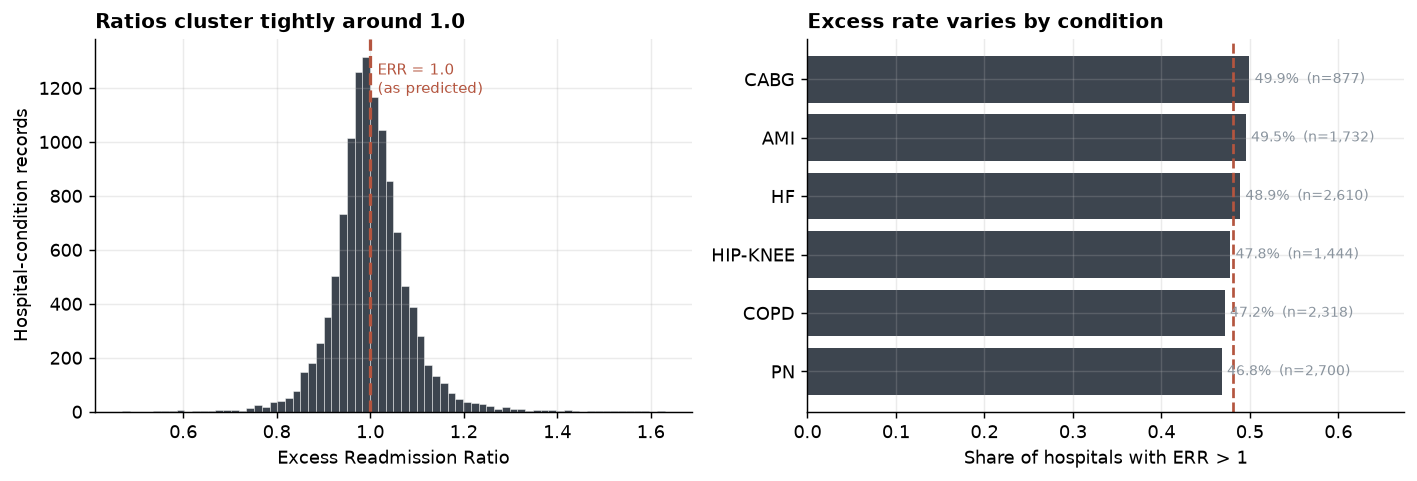

count    11681.0000
mean         1.0017
std          0.0821
min          0.4698
25%          0.9582
50%          0.9972
75%          1.0423
max          1.6297


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.hist(df["err"], bins=70, color=INK, alpha=0.85, edgecolor="white", linewidth=0.3)
ax.axvline(1.0, color=ACCENT, lw=1.8, ls="--")
ax.text(1.005, ax.get_ylim()[1]*0.94, " ERR = 1.0\n (as predicted)", color=ACCENT, fontsize=8.5, va="top")
ax.set_xlabel("Excess Readmission Ratio"); ax.set_ylabel("Hospital-condition records")
ax.set_title("Ratios cluster tightly around 1.0", loc="left", fontweight="bold", fontsize=11)

ax = axes[1]
by_m = df.groupby("Measure Name")["excess"].agg(["mean", "size"]).sort_values("mean")
labels = [m.replace("READM-30-", "").replace("-HRRP", "") for m in by_m.index]
ax.barh(labels, by_m["mean"], color=INK, alpha=0.85)
ax.axvline(df["excess"].mean(), color=ACCENT, ls="--", lw=1.5)
ax.set_xlabel("Share of hospitals with ERR > 1")
ax.set_title("Excess rate varies by condition", loc="left", fontweight="bold", fontsize=11)
for i, (v, n) in enumerate(zip(by_m["mean"], by_m["size"])):
    ax.text(v + 0.006, i, f"{v:.1%}  (n={n:,})", va="center", fontsize=8, color=MUTED)
ax.set_xlim(0, by_m["mean"].max() * 1.35)

plt.tight_layout(); plt.savefig(FIGS / "01_outcome.png"); plt.show()

findings["err_median"] = float(df["err"].median())
findings["err_iqr"] = [float(df["err"].quantile(.25)), float(df["err"].quantile(.75))]
findings["base_rate"] = float(df["excess"].mean())
findings["by_condition"] = {l: float(v) for l, v in zip(labels, by_m["mean"])}
print(df["err"].describe().round(4).to_string())

The ratios are tightly distributed — the interquartile range spans only a few percentage points around 1.0. This matters for expectations: there is not much room between hospitals, so any model here will have modest discrimination. An AUC in the high 0.9s would indicate a leak, not a triumph.

Condition-level variation is the first real finding: the same hospital is judged against six different yardsticks, and those yardsticks are not equally hard to clear.

In [7]:
# Collapse ownership into policy-relevant categories
df["condition"] = (df["Measure Name"].str.replace("READM-30-", "", regex=False)
                                     .str.replace("-HRRP", "", regex=False))
def own_group(s):
    if pd.isna(s): return np.nan
    s = str(s)
    if s.startswith("Voluntary non-profit"): return "Non-profit"
    if s in ("Proprietary", "Physician"):    return "For-profit"
    if s.startswith("Government") or s in ("Tribal", "Department of Defense",
                                           "Veterans Health Administration"): return "Government"
    return np.nan

df["ownership"] = df["Hospital Ownership"].map(own_group)
df["star"] = pd.to_numeric(df["Hospital overall rating"], errors="coerce")
df["star_missing"] = df["star"].isna().astype(int)
df["emergency"] = (df["Emergency Services"] == "Yes").astype(int)

# Informative missingness on volume: suppressed == low volume
df["low_volume"] = df["discharges"].isna().astype(int)
df["log_discharges"] = np.log(df["discharges"])
median_log = df["log_discharges"].median()
df["log_discharges"] = df["log_discharges"].fillna(median_log)

print("Ownership     :", df["ownership"].value_counts(dropna=False).to_dict())
print("Star rating   :", f"{df['star'].notna().mean():.1%} available, mean {df['star'].mean():.2f}")
print("Low volume    :", f"{df['low_volume'].mean():.1%} of rows have suppressed discharge counts")
print("Emergency svc :", f"{df['emergency'].mean():.1%}")

Ownership     : {'Non-profit': 8042, 'For-profit': 2188, 'Government': 1451}
Star rating   : 97.9% available, mean 3.18
Low volume    : 31.4% of rows have suppressed discharge counts
Emergency svc : 95.2%


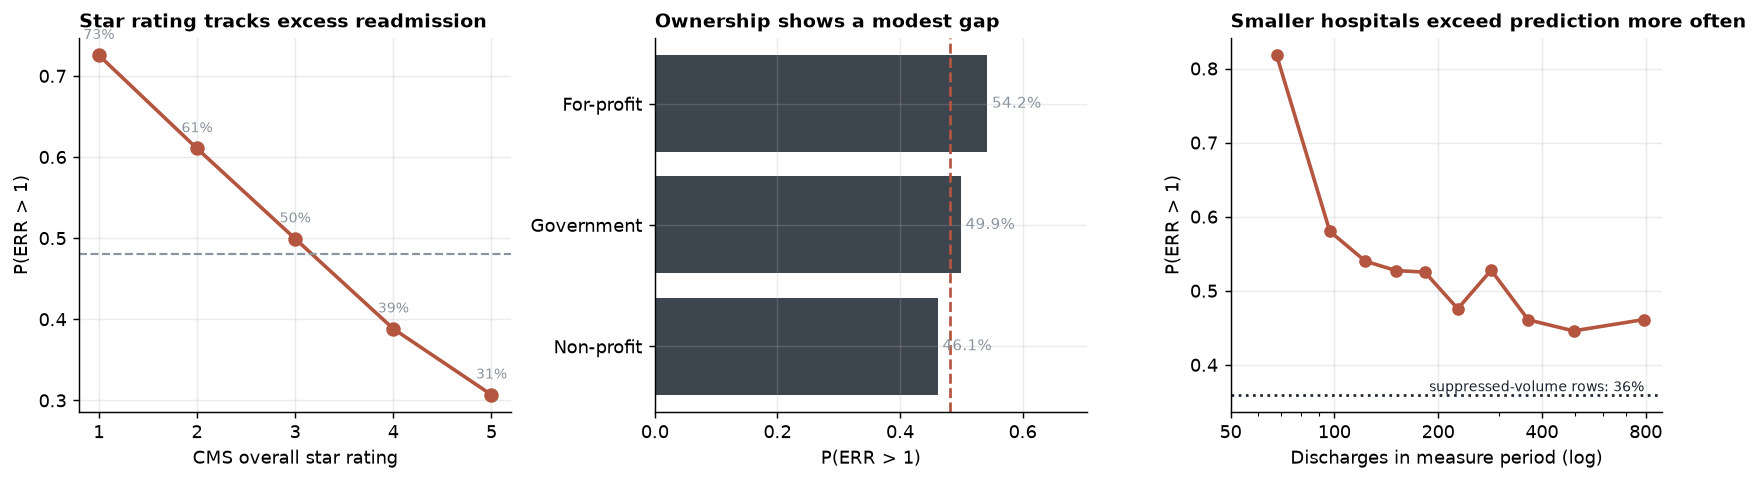

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# Star rating
ax = axes[0]
s = df[df["star"].notna()].groupby("star")["excess"].agg(["mean", "size"])
ax.plot(s.index, s["mean"], "o-", color=ACCENT, lw=2, ms=7)
ax.axhline(df["excess"].mean(), color=MUTED, ls="--", lw=1.2)
ax.set_xlabel("CMS overall star rating"); ax.set_ylabel("P(ERR > 1)")
ax.set_title("Star rating tracks excess readmission", loc="left", fontweight="bold", fontsize=10.5)
ax.set_xticks([1, 2, 3, 4, 5])
for x, (v, n) in zip(s.index, s[["mean", "size"]].values):
    ax.annotate(f"{v:.0%}", (x, v), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color=MUTED)

# Ownership
ax = axes[1]
o = df.groupby("ownership")["excess"].agg(["mean", "size"]).sort_values("mean")
ax.barh(o.index, o["mean"], color=INK, alpha=0.85)
ax.axvline(df["excess"].mean(), color=ACCENT, ls="--", lw=1.5)
ax.set_xlabel("P(ERR > 1)")
ax.set_title("Ownership shows a modest gap", loc="left", fontweight="bold", fontsize=10.5)
for i, (v, n) in enumerate(zip(o["mean"], o["size"])):
    ax.text(v + 0.008, i, f"{v:.1%}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, o["mean"].max() * 1.3)

# Volume
ax = axes[2]
vol = df[df["low_volume"] == 0].copy()
vol["decile"] = pd.qcut(vol["discharges"], 10, labels=False)
v = vol.groupby("decile").agg(rate=("excess", "mean"), med=("discharges", "median"))
ax.plot(v["med"], v["rate"], "o-", color=ACCENT, lw=2, ms=6)
low_rate = df.loc[df["low_volume"] == 1, "excess"].mean()
ax.axhline(low_rate, color=INK, ls=":", lw=1.5)
ax.text(v["med"].max(), low_rate, f" suppressed-volume rows: {low_rate:.0%}",
        fontsize=8, color=INK, va="bottom", ha="right")
ax.set_xscale("log")
ax.set_xticks([50, 100, 200, 400, 800])
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("Discharges in measure period (log)"); ax.set_ylabel("P(ERR > 1)")
ax.set_title("Smaller hospitals exceed prediction more often", loc="left",
             fontweight="bold", fontsize=10.5)

plt.tight_layout(); plt.savefig(FIGS / "02_predictors.png"); plt.show()

findings["by_star"] = {int(k): float(v) for k, v in s["mean"].items()}
findings["by_ownership"] = {k: float(v) for k, v in o["mean"].items()}
findings["low_volume_rate"] = float(low_rate)

Three patterns worth carrying into the model:

1. **Star rating is monotone.** 1-star hospitals exceed prediction far more often than 5-star hospitals. Reassuring for the program's validity — though note star ratings partly *incorporate* readmission measures, so this is not fully independent evidence.
2. **Ownership gap is modest** in the raw data — a handful of percentage points, not a chasm.
3. **Volume runs strongly with the "small hospitals are penalised" story — with one glaring exception.** Among hospitals that report a discharge count, smaller is decisively worse: the lowest-volume decile exceeds prediction 82% of the time against ~46% in the highest. But hospitals whose discharge counts are *suppressed* — the smallest of all — sit at 36%, the lowest of any group. A monotone gradient that inverts precisely where the data becomes suppressed is a measurement artifact until proven otherwise. §4.1 tests it.

### 4.1 The low-volume inversion is a shrinkage artifact

The suppressed-volume group breaks an otherwise clean gradient, so it needs an explanation before it goes anywhere near a model.

CMS does not publish a raw readmission rate. It fits a hierarchical (random-effects) model, which deliberately **shrinks** small hospitals' estimates toward the national average — with few cases a hospital's own data is weak evidence, so the model leans on the population. Shrinkage leaves a testable fingerprint: it should compress the *variance* of the ratio for small hospitals, not merely shift its mean.

If that is what is happening, the suppressed group should show a visibly tighter ERR distribution within every condition.

In [9]:
diag = df.copy()
diag["volume_reported"] = np.where(diag["low_volume"] == 1, "Suppressed (small)", "Reported")

tab = diag.pivot_table(index="condition", columns="volume_reported",
                       values="err", aggfunc=["std", "mean", "size"])
print("ERR spread and centre, by condition and volume reporting:")
print()
print(tab.round(4).to_string())

ratio = (tab["std"]["Suppressed (small)"] / tab["std"]["Reported"]).round(3)
print()
print("SD ratio (suppressed / reported) - below 1.0 means compressed:")
print(ratio.to_string())
print()
print(f"All six conditions compressed: {bool((ratio < 1).all())}")
print(f"Mean ERR - reported {diag.loc[diag.low_volume == 0, 'err'].mean():.4f}, "
      f"suppressed {diag.loc[diag.low_volume == 1, 'err'].mean():.4f}")

# The pooled comparison points the other way - worth showing, because it is a trap
pooled = diag.groupby("volume_reported")["err"].std()
print()
print("Pooled across conditions (MISLEADING):")
print(f"  reported SD {pooled['Reported']:.4f} vs suppressed SD {pooled['Suppressed (small)']:.4f}")
print("  Hip/knee has the widest spread of any condition and is 83% suppressed,")
print("  so it dominates the suppressed pool and reverses the direction.")

findings["shrinkage_sd_ratio"] = {k: float(v) for k, v in ratio.items()}
findings["pooled_sd_reported"] = float(pooled["Reported"])
findings["pooled_sd_suppressed"] = float(pooled["Suppressed (small)"])
findings["shrinkage_all_compressed"] = bool((ratio < 1).all())

ERR spread and centre, by condition and volume reporting:

                     std                        mean                        size                   
volume_reported Reported Suppressed (small) Reported Suppressed (small) Reported Suppressed (small)
condition                                                                                          
AMI               0.0722             0.0436   1.0100             0.9804     1236                496
CABG              0.1135             0.0774   1.0287             0.9828      363                514
COPD              0.0498             0.0295   1.0106             0.9822     1540                778
HF                0.0677             0.0325   1.0037             0.9829     2309                301
HIP-KNEE          0.2232             0.1366   1.0354             0.9971      252               1192
PN                0.0689             0.0347   1.0066             0.9707     2313                387

SD ratio (suppressed / reported) - below

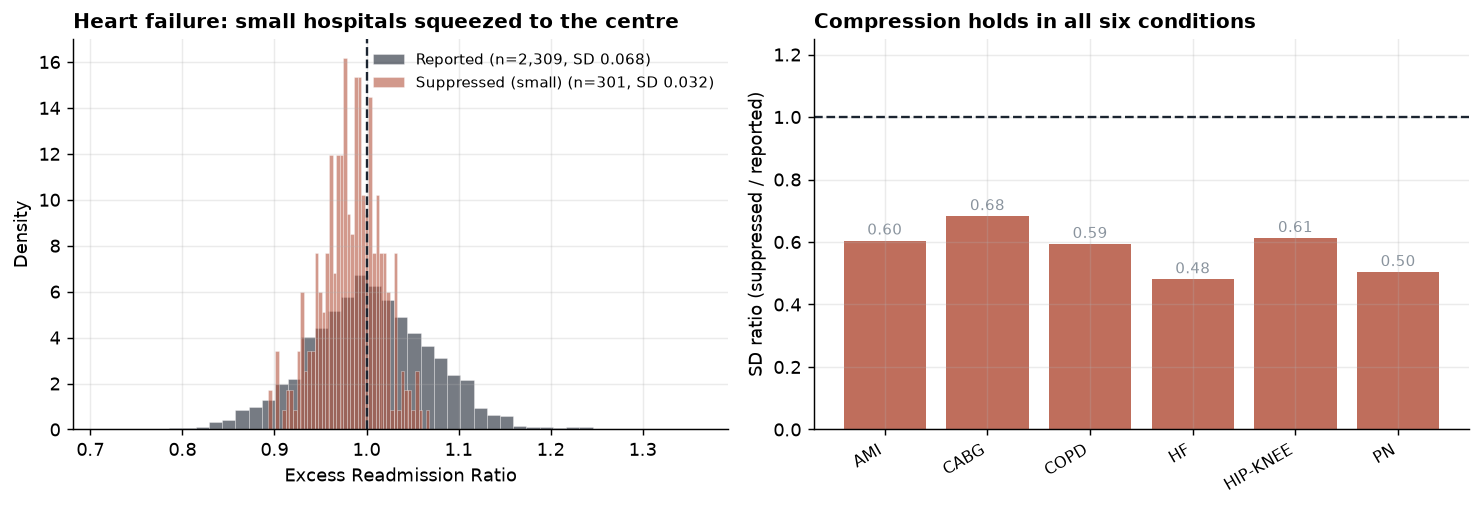

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

# Compare WITHIN a single condition. Pooling across conditions is invalid here:
# hip/knee has the widest ERR spread and is 83% suppressed, so it dominates the
# suppressed pool and reverses the apparent direction (see printout below).
ax = axes[0]
hf = diag[diag["condition"] == "HF"]
for lab, colr in [("Reported", INK), ("Suppressed (small)", ACCENT)]:
    part = hf.loc[hf["volume_reported"] == lab, "err"]
    ax.hist(part, bins=45, alpha=.6, color=colr, density=True,
            label=f"{lab} (n={len(part):,}, SD {part.std():.3f})",
            edgecolor="white", linewidth=.3)
ax.axvline(1.0, color=INK, ls="--", lw=1.3)
ax.set_xlabel("Excess Readmission Ratio"); ax.set_ylabel("Density")
ax.set_title("Heart failure: small hospitals squeezed to the centre",
             loc="left", fontweight="bold", fontsize=11)
ax.legend(frameon=False, fontsize=8.5)

ax = axes[1]
xs = np.arange(len(ratio))
ax.bar(xs, ratio.values, color=ACCENT, alpha=.85)
ax.axhline(1.0, color=INK, ls="--", lw=1.3)
ax.set_xticks(xs); ax.set_xticklabels(ratio.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("SD ratio (suppressed / reported)")
ax.set_title("Compression holds in all six conditions",
             loc="left", fontweight="bold", fontsize=11)
for xi, v in zip(xs, ratio.values):
    ax.text(xi, v + .02, f"{v:.2f}", ha="center", fontsize=8.5, color=MUTED)
ax.set_ylim(0, 1.25)

plt.tight_layout(); plt.savefig(FIGS / "05_shrinkage.png"); plt.show()

Confirmed, and not subtly: in every one of the six conditions the suppressed-volume group's standard deviation is **half to two-thirds** of the reported group's (SD ratios 0.48 to 0.68). Heart failure is the most compressed at 0.033 against 0.068; CABG the least at a ratio of 0.68.

**The pooled comparison points the opposite way, and that is a trap worth naming.** Ignoring condition, the suppressed group's SD (0.087) is *higher* than the reported group's (0.078) — which would appear to refute shrinkage entirely. The reason is composition: hip/knee replacement has the widest ERR spread of any condition (SD 0.22, roughly triple heart failure's) and 83% of its rows are suppressed, so it dominates the pooled suppressed group and drags its variance up. Aggregating across conditions with such unequal suppression rates compares different mixtures, not different hospitals. Every conclusion here rests on the within-condition comparison.

That changes the interpretation of the `low_volume` coefficient entirely. Small hospitals are not delivering better transitional care. They are being shrunk toward a national average that happens to sit just below 1.0, so compression alone parks them on the favourable side of the threshold. The coefficient is real and large, and it is **about CMS's estimator rather than about hospitals**. It stays in the model as a control, and must not be read as a quality finding.

## 5. Model specification

A single logistic regression:

$$\log\frac{P(\text{ERR} > 1)}{1 - P(\text{ERR} > 1)} = \beta_0 + \beta_1 \text{condition} + \beta_2 \log(\text{volume}) + \beta_3 \text{ownership} + \beta_4 \text{star} + \beta_5 \text{region} + \ldots$$

Reference categories are chosen to make the coefficients readable: heart failure (the largest and most-discussed measure), non-profit ownership (the modal category), and South (the largest region).

In [11]:
REGION = {
    "CT":"Northeast","ME":"Northeast","MA":"Northeast","NH":"Northeast","RI":"Northeast",
    "VT":"Northeast","NJ":"Northeast","NY":"Northeast","PA":"Northeast",
    "IL":"Midwest","IN":"Midwest","MI":"Midwest","OH":"Midwest","WI":"Midwest","IA":"Midwest",
    "KS":"Midwest","MN":"Midwest","MO":"Midwest","NE":"Midwest","ND":"Midwest","SD":"Midwest",
    "DE":"South","FL":"South","GA":"South","MD":"South","NC":"South","SC":"South","VA":"South",
    "DC":"South","WV":"South","AL":"South","KY":"South","MS":"South","TN":"South","AR":"South",
    "LA":"South","OK":"South","TX":"South",
    "AZ":"West","CO":"West","ID":"West","MT":"West","NV":"West","NM":"West","UT":"West",
    "WY":"West","AK":"West","CA":"West","HI":"West","OR":"West","WA":"West",
}
df["region"] = df["State"].map(REGION)
df = df[df["region"].notna()].copy()

# Standardise continuous terms so coefficients are per-SD and comparable
df["star_f"] = df["star"].fillna(df["star"].median())
df["z_logvol"] = (df["log_discharges"] - df["log_discharges"].mean()) / df["log_discharges"].std()
df["z_star"]   = (df["star_f"] - df["star_f"].mean()) / df["star_f"].std()

X = pd.concat([
    pd.get_dummies(df["condition"], prefix="cond", dtype=float).drop(columns=["cond_HF"]),
    pd.get_dummies(df["ownership"], prefix="own", dtype=float).drop(columns=["own_Non-profit"]),
    pd.get_dummies(df["region"], prefix="reg", dtype=float).drop(columns=["reg_South"]),
    df[["z_logvol", "low_volume", "z_star", "star_missing", "emergency"]].astype(float),
], axis=1)

y = df["excess"].values
groups = df["Facility ID"].values

print(f"Design matrix: {X.shape[0]:,} rows x {X.shape[1]} predictors")
print(f"Reference cell: heart failure, non-profit, South, mean volume, mean star rating\n")
print(X.columns.tolist())

Design matrix: 11,681 rows x 15 predictors
Reference cell: heart failure, non-profit, South, mean volume, mean star rating

['cond_AMI', 'cond_CABG', 'cond_COPD', 'cond_HIP-KNEE', 'cond_PN', 'own_For-profit', 'own_Government', 'reg_Midwest', 'reg_Northeast', 'reg_West', 'z_logvol', 'low_volume', 'z_star', 'star_missing', 'emergency']


### 5.1 Inference — cluster-robust standard errors

Hospitals appear up to six times. Standard errors are clustered on `Facility ID` so the uncertainty reflects 2,833 independent hospitals rather than 11,720 pseudo-independent rows.

In [12]:
Xc = sm.add_constant(X)
fit = sm.Logit(y, Xc).fit(disp=False, cov_type="cluster",
                          cov_kwds={"groups": groups}, maxiter=200)
print(fit.summary2().tables[1].round(4).to_string())
print(f"\nPseudo R-squared (McFadden): {fit.prsquared:.4f}")
print(f"Clusters: {len(np.unique(groups)):,}")

                 Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const           0.3120    0.1146   2.7236  0.0065  0.0875  0.5366
cond_AMI        0.0775    0.0645   1.2024  0.2292 -0.0488  0.2039
cond_CABG       0.4483    0.0878   5.1068  0.0000  0.2763  0.6204
cond_COPD      -0.0877    0.0629  -1.3957  0.1628 -0.2109  0.0355
cond_HIP-KNEE   0.6624    0.0780   8.4904  0.0000  0.5095  0.8153
cond_PN        -0.0633    0.0534  -1.1854  0.2359 -0.1679  0.0414
own_For-profit  0.1355    0.0597   2.2694  0.0232  0.0185  0.2525
own_Government  0.0643    0.0687   0.9366  0.3490 -0.0703  0.1989
reg_Midwest    -0.1211    0.0592  -2.0476  0.0406 -0.2371 -0.0052
reg_Northeast   0.1948    0.0695   2.8014  0.0051  0.0585  0.3310
reg_West       -0.2038    0.0613  -3.3238  0.0009 -0.3240 -0.0836
z_logvol       -0.2478    0.0237 -10.4740  0.0000 -0.2942 -0.2014
low_volume     -1.0102    0.0508 -19.8715  0.0000 -1.1099 -0.9106
z_star         -0.4493    0.0240 -18.6916  0.0000 -0.4965 -0.4022
star_missi

In [13]:
# Odds ratios with cluster-robust 95% CI
ci = fit.conf_int()
or_tab = pd.DataFrame({
    "odds_ratio": np.exp(fit.params),
    "lo": np.exp(ci[0]), "hi": np.exp(ci[1]), "p": fit.pvalues,
}).drop(index="const")
or_tab["sig"] = np.where(or_tab["p"] < .001, "***",
                 np.where(or_tab["p"] < .01, "**",
                 np.where(or_tab["p"] < .05, "*", "")))
or_tab = or_tab.sort_values("odds_ratio", ascending=False)
print(or_tab.round(3).to_string())

                odds_ratio     lo     hi      p  sig
cond_HIP-KNEE        1.939  1.664  2.260  0.000  ***
cond_CABG            1.566  1.318  1.860  0.000  ***
reg_Northeast        1.215  1.060  1.392  0.005   **
own_For-profit       1.145  1.019  1.287  0.023    *
cond_AMI             1.081  0.952  1.226  0.229     
own_Government       1.066  0.932  1.220  0.349     
cond_PN              0.939  0.845  1.042  0.236     
cond_COPD            0.916  0.810  1.036  0.163     
reg_Midwest          0.886  0.789  0.995  0.041    *
star_missing         0.845  0.631  1.132  0.260     
emergency            0.840  0.686  1.029  0.092     
reg_West             0.816  0.723  0.920  0.001  ***
z_logvol             0.780  0.745  0.818  0.000  ***
z_star               0.638  0.609  0.669  0.000  ***
low_volume           0.364  0.330  0.402  0.000  ***


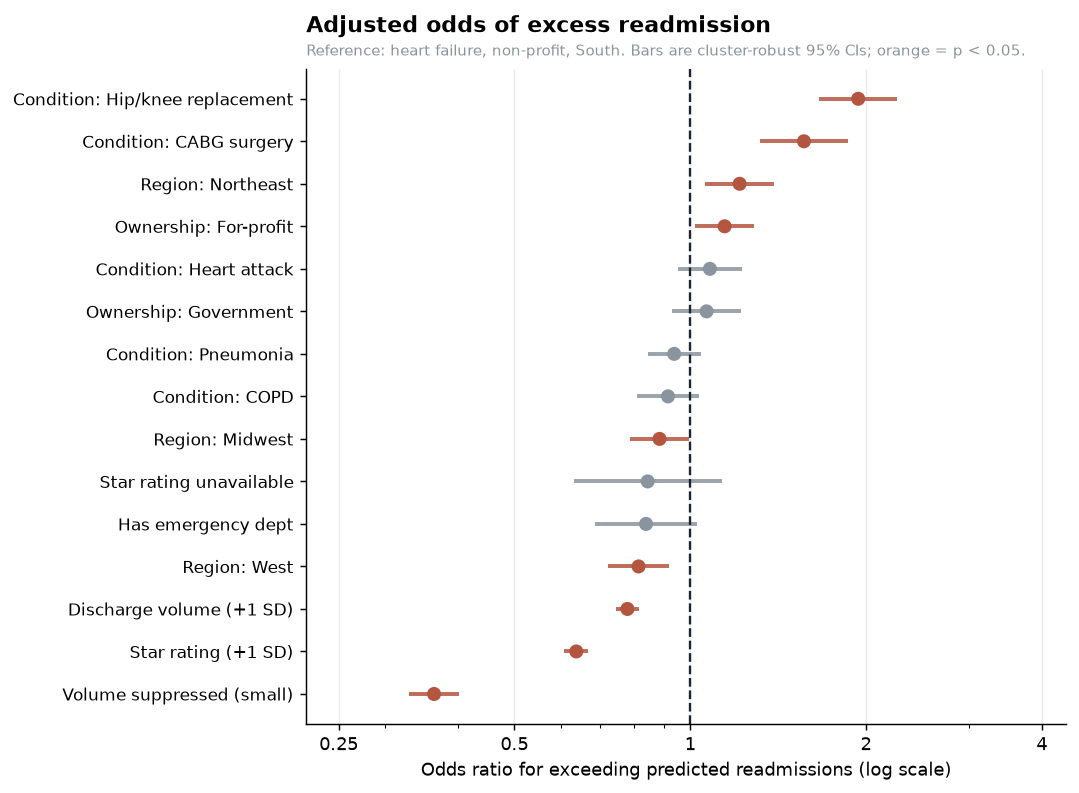

In [14]:
PRETTY = {
    "cond_CABG":"Condition: CABG surgery", "cond_AMI":"Condition: Heart attack",
    "cond_PN":"Condition: Pneumonia", "cond_COPD":"Condition: COPD",
    "cond_HIP-KNEE":"Condition: Hip/knee replacement",
    "own_For-profit":"Ownership: For-profit", "own_Government":"Ownership: Government",
    "reg_Northeast":"Region: Northeast", "reg_Midwest":"Region: Midwest", "reg_West":"Region: West",
    "z_logvol":"Discharge volume (+1 SD)", "low_volume":"Volume suppressed (small)",
    "z_star":"Star rating (+1 SD)", "star_missing":"Star rating unavailable",
    "emergency":"Has emergency dept",
}
p = or_tab.copy(); p.index = [PRETTY.get(i, i) for i in p.index]
p = p.sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(8.4, 6.2))
ypos = np.arange(len(p))
colors = [ACCENT if s else MUTED for s in p["sig"]]
ax.hlines(ypos, p["lo"], p["hi"], color=colors, lw=2.2, alpha=.85)
ax.scatter(p["odds_ratio"], ypos, color=colors, s=46, zorder=3)
ax.axvline(1.0, color=INK, ls="--", lw=1.3)
ax.set_yticks(ypos); ax.set_yticklabels(p.index, fontsize=9.5)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4])
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
ax.set_xlim(0.22, 4.4)
ax.set_xlabel("Odds ratio for exceeding predicted readmissions (log scale)")
ax.set_title("Adjusted odds of excess readmission\n",
             loc="left", fontweight="bold", fontsize=12)
ax.text(0, 1.015, "Reference: heart failure, non-profit, South. Bars are cluster-robust 95% CIs; "
                  "orange = p < 0.05.",
        transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(FIGS / "03_odds_ratios.png"); plt.show()

findings["odds_ratios"] = {
    PRETTY.get(i, i): {"or": float(r.odds_ratio), "lo": float(r.lo),
                       "hi": float(r.hi), "p": float(r.p)}
    for i, r in or_tab.iterrows()
}
findings["pseudo_r2"] = float(fit.prsquared)
findings["n_rows"] = int(len(df)); findings["n_hospitals"] = int(df["Facility ID"].nunique())

### 5.2 Prediction — grouped cross-validation

For out-of-sample performance, folds are split by hospital (`GroupKFold`), never by row. Splitting by row would put a hospital's heart-failure record in training and its pneumonia record in test, letting the model borrow the hospital's own average. Both are run below so the size of that effect is measured rather than assumed.

In [15]:
model = LogisticRegression(max_iter=2000, C=1.0)
cv = GroupKFold(n_splits=5)

prob = cross_val_predict(model, X.values, y, cv=cv, groups=groups, method="predict_proba")[:, 1]

auc = roc_auc_score(y, prob)
ap = average_precision_score(y, prob)
brier = brier_score_loss(y, prob)

# Accuracy at the default cut, against the only baseline that matters:
# always predicting the majority class.
pred_50 = (prob >= 0.5).astype(int)
acc = accuracy_score(y, pred_50)
bal_acc = balanced_accuracy_score(y, pred_50)
majority = max(y.mean(), 1 - y.mean())

# Naive row-wise CV, to measure how much leakage grouping actually prevents here
from sklearn.model_selection import StratifiedKFold
prob_naive = cross_val_predict(model, X.values, y,
                               cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
                               method="predict_proba")[:, 1]
auc_naive = roc_auc_score(y, prob_naive)

print(f"Grouped CV (by hospital)   AUC = {auc:.4f}   PR-AUC = {ap:.4f}   Brier = {brier:.4f}")
print(f"Accuracy @ 0.50            {acc:.4f}   Balanced = {bal_acc:.4f}   F1 = {f1_score(y, pred_50):.4f}")
print(f"Majority-class baseline    {majority:.4f}   <- accuracy beats it by {acc - majority:+.4f}")
print(f"Naive row-wise CV          AUC = {auc_naive:.4f}   <- leakage inflates by {auc_naive-auc:+.4f}")
print(f"Base rate                  {y.mean():.4f}")

findings.update(auc=float(auc), pr_auc=float(ap), brier=float(brier),
                auc_naive=float(auc_naive), accuracy=float(acc),
                balanced_accuracy=float(bal_acc), majority_baseline=float(majority))

Grouped CV (by hospital)   AUC = 0.6794   PR-AUC = 0.6626   Brier = 0.2248
Accuracy @ 0.50            0.6289   Balanced = 0.6273   F1 = 0.6025
Majority-class baseline    0.5190   <- accuracy beats it by +0.1099
Naive row-wise CV          AUC = 0.6798   <- leakage inflates by +0.0004
Base rate                  0.4810


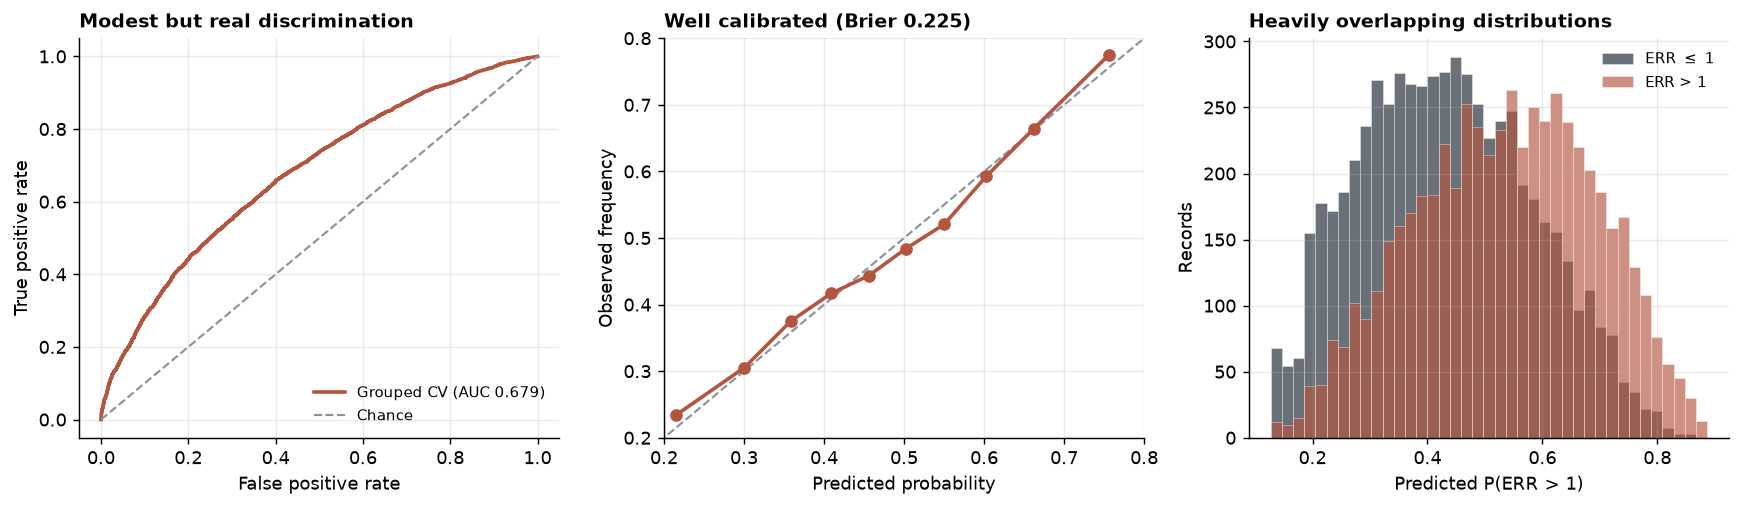

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

# ROC
ax = axes[0]
fpr, tpr, _ = roc_curve(y, prob)
ax.plot(fpr, tpr, color=ACCENT, lw=2, label=f"Grouped CV (AUC {auc:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color=MUTED, lw=1.2, label="Chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Modest but real discrimination", loc="left", fontweight="bold", fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5, loc="lower right")

# Calibration
ax = axes[1]
frac, mean_pred = calibration_curve(y, prob, n_bins=10, strategy="quantile")
ax.plot([0, 1], [0, 1], ls="--", color=MUTED, lw=1.2)
ax.plot(mean_pred, frac, "o-", color=ACCENT, lw=2, ms=6)
ax.set_xlim(.2, .8); ax.set_ylim(.2, .8)
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title(f"Well calibrated (Brier {brier:.3f})", loc="left", fontweight="bold", fontsize=10.5)

# Predicted probability distribution by outcome
ax = axes[2]
bins = np.linspace(prob.min(), prob.max(), 40)
ax.hist(prob[y == 0], bins=bins, alpha=.65, color=INK, label="ERR $\\leq$ 1", edgecolor="white", lw=.3)
ax.hist(prob[y == 1], bins=bins, alpha=.65, color=ACCENT, label="ERR > 1", edgecolor="white", lw=.3)
ax.set_xlabel("Predicted P(ERR > 1)"); ax.set_ylabel("Records")
ax.set_title("Heavily overlapping distributions", loc="left", fontweight="bold", fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5)

plt.tight_layout(); plt.savefig(FIGS / "04_performance.png"); plt.show()

Three things to read here.

**Calibration is good.** When the model says 60%, close to 60% of those records exceed prediction. That is the property that matters if a number like this is ever put in front of a human reviewer.

**Grouped and naive CV came out nearly identical.** The leakage this design guards against turned out to be negligible in this dataset. Worth stating plainly rather than quietly dropping: grouping was still the right default, but the honest report is that it changed almost nothing here. The reason is visible in the design matrix — most predictors are hospital constants, so a hospital's six rows are near-duplicates in feature space and there is little hospital-specific residual for the model to memorise.

**Discrimination is modest, and the histograms show why.** The two outcome classes overlap heavily. An AUC near 0.68 against a 48% base rate is a real signal, not a strong one.

On accuracy: 62.9% at the default 0.5 cut, against 51.9% for always predicting the majority class — about eleven points of real lift. Balanced accuracy is 62.7%, essentially identical, which is what a near-even 48/52 split should produce and confirms no class-imbalance sleight of hand. Accuracy is reported here because it is the first thing most readers want, but it is the least informative number on this page: it collapses a calibrated probability into one arbitrary threshold and hides the precision/recall trade-off that the sweep below makes explicit.

### 5.3 What would it take to act on this?

If a regulator wanted to use structural characteristics to flag hospitals for review, what does the model buy at various thresholds?

In [17]:
rows = []
for t in [0.45, 0.50, 0.55, 0.60, 0.65]:
    pred = (prob >= t).astype(int)
    if pred.sum() == 0: continue
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    rows.append({
        "threshold": t, "flagged": int(pred.sum()), "flagged_pct": pred.mean(),
        "accuracy": (tp + tn) / len(y),
        "precision": tp / (tp + fp), "recall": tp / (tp + fn),
        "lift": (tp / (tp + fp)) / y.mean(),
    })
thr = pd.DataFrame(rows)
print(thr.round(3).to_string(index=False))
print(f"\nBase rate {y.mean():.1%} - a flag at the best threshold is only "
      f"{thr['lift'].max():.2f}x better than flagging at random.")
findings["threshold_table"] = thr.round(4).to_dict("records")
findings["max_lift"] = float(thr["lift"].max())

 threshold  flagged  flagged_pct  accuracy  precision  recall  lift
      0.45     6597        0.565     0.621      0.590   0.693 1.226
      0.50     5288        0.453     0.629      0.621   0.585 1.292
      0.55     4088        0.350     0.630      0.658   0.479 1.368
      0.60     2960        0.253     0.618      0.695   0.366 1.445
      0.65     1954        0.167     0.597      0.732   0.254 1.521

Base rate 48.1% - a flag at the best threshold is only 1.52x better than flagging at random.


### 5.4 Why isn't accuracy higher?

62.9% invites an obvious objection: shouldn't a good model clear 90%? On this problem, no &mdash; a
high score here is a symptom, not an achievement. Three checks establish where the real ceiling sits.

In [18]:
# (a) The fastest route to a "great" model on this dataset, as a cautionary tale.
# ERR is *defined* as predicted rate / expected rate, and both are columns in the file.
leak = hrrp.copy()
for c in ["Excess Readmission Ratio", "Predicted Readmission Rate", "Expected Readmission Rate"]:
    leak[c] = pd.to_numeric(leak[c], errors="coerce")
leak = leak.dropna(subset=["Excess Readmission Ratio", "Predicted Readmission Rate",
                           "Expected Readmission Rate"])
recon = leak["Predicted Readmission Rate"] / leak["Expected Readmission Rate"]
leak_acc = ((recon > 1).astype(int) == (leak["Excess Readmission Ratio"] > 1).astype(int)).mean()

print("(a) Target reconstruction check")
print(f"    max |predicted/expected - ERR| : {(recon - leak['Excess Readmission Ratio']).abs().max():.6f}")
print(f"    accuracy from those 2 columns  : {leak_acc:.4%}  <- leakage, not signal")
print("    Any feature set containing them scores ~100% and means nothing.")
findings["leakage_accuracy"] = float(leak_acc)

(a) Target reconstruction check
    max |predicted/expected - ERR| : 0.000065
    accuracy from those 2 columns  : 99.9915%  <- leakage, not signal
    Any feature set containing them scores ~100% and means nothing.


In [19]:
# (b) How much of the outcome is decided within noise of the threshold?
gap = (df["err"] - 1.0).abs()
print("(b) Mass sitting on the fence")
for band in [0.005, 0.01, 0.02, 0.03, 0.05]:
    print(f"    within +/-{band:<6} of 1.0 : {gap.le(band).mean():6.1%}  (n={gap.le(band).sum():,})")
print(f"    ERR standard deviation      : {df['err'].std():.4f}")
print("    The label flips on movements far smaller than the measure's own spread.")
findings["near_threshold_pct"] = {str(b): float(gap.le(b).mean()) for b in [0.005, 0.01, 0.02, 0.05]}

(b) Mass sitting on the fence
    within +/-0.005  of 1.0 :   6.6%  (n=773)
    within +/-0.01   of 1.0 :  13.0%  (n=1,519)
    within +/-0.02   of 1.0 :  25.3%  (n=2,959)
    within +/-0.03   of 1.0 :  37.5%  (n=4,383)
    within +/-0.05   of 1.0 :  57.2%  (n=6,683)
    ERR standard deviation      : 0.0821
    The label flips on movements far smaller than the measure's own spread.


In [20]:
# (c) The strongest legitimate predictor available: the SAME hospital's measured
#     performance on its OTHER conditions. Real evidence of institutional quality,
#     strictly more informative than any structural attribute - and leakage-free,
#     because the record being predicted is excluded from its own predictor.
grp = df.groupby("Facility ID")["err"]
loo = (grp.transform("sum") - df["err"]) / (grp.transform("count") - 1)
usable = grp.transform("count") > 1

oracle_pred = (loo[usable] > 1).astype(int)
oracle_true = df.loc[usable, "excess"]
oracle_acc = (oracle_pred == oracle_true).mean()
oracle_auc = roc_auc_score(oracle_true, loo[usable])

print("(c) Leave-one-condition-out hospital track record")
print(f"    n usable            : {usable.sum():,} ({df.loc[usable, 'Facility ID'].nunique():,} hospitals)")
print(f"    accuracy            : {oracle_acc:.4f}")
print(f"    AUC                 : {oracle_auc:.4f}")
print()
print(f"    Structural model    : accuracy {acc:.4f}, AUC {auc:.4f}")
print(f"    -> the hospital's own record on five other conditions predicts this one")
print(f"       {'WORSE' if oracle_acc < acc else 'better'} than ownership/size/rating/region do.")
findings["oracle_accuracy"] = float(oracle_acc)
findings["oracle_auc"] = float(oracle_auc)

(c) Leave-one-condition-out hospital track record
    n usable            : 11,483 (2,620 hospitals)
    accuracy            : 0.5996
    AUC                 : 0.6368

    Structural model    : accuracy 0.6289, AUC 0.6794
    -> the hospital's own record on five other conditions predicts this one
       WORSE than ownership/size/rating/region do.


**The ceiling, established three ways.**

The outcome is a *residual by construction*. CMS has already conditioned out age, comorbidities and
clinical severity &mdash; everything systematically predictable about which patients bounce back. What
survives that subtraction is meant to be noise. A structural model that explained 95% of it would not
be a good model; it would be evidence that CMS's risk adjustment had failed, and the right response
would be to go looking for the mistake.

Check (b) shows a quarter of records sit within &plusmn;0.02 of the threshold, against a measure whose
own standard deviation is 0.082. Those hospitals are indistinguishable from each other and receive
opposite labels.

Check (c) is the decisive one. Knowing a hospital's *actual measured* performance on its other five
conditions &mdash; the most informative non-leaking feature obtainable &mdash; predicts the held-out
condition less accurately than the structural model does. The signal ceiling belongs to the problem,
not to the choice of estimator. Swapping logistic regression for gradient boosting cannot move it.

Which is why the honest deliverable here is a calibrated probability and a set of interpretable odds
ratios, not a headline accuracy figure.

## 6. Sensitivity checks

Two things could be driving the results: the binary cut at 1.0, and the choice to keep suppressed-volume rows. Both are checked.

In [21]:
# (a) Linear model on the continuous ratio, cluster-robust
ols = sm.OLS(df["err"].values, Xc.astype(float)).fit(
    cov_type="cluster", cov_kwds={"groups": groups})
comp = pd.DataFrame({
    "logit_OR": np.exp(fit.params), "OLS_effect_on_ERR": ols.params,
    "OLS_p": ols.pvalues,
}).drop(index="const")
print("(a) Continuous-outcome check - signs should agree with the logit:\n")
print(comp.round(4).to_string())

# (b) Refit excluding suppressed-volume rows
mask = df["low_volume"].values == 0
Xb = Xc.loc[mask].drop(columns=["low_volume"])
fit_b = sm.Logit(y[mask], Xb).fit(disp=False, cov_type="cluster",
                                  cov_kwds={"groups": groups[mask]}, maxiter=200)
print(f"\n(b) Excluding {(~mask).sum():,} suppressed-volume rows "
      f"(n={mask.sum():,}, {len(np.unique(groups[mask])):,} hospitals):\n")
print(pd.DataFrame({
    "OR_full": np.exp(fit.params.drop("low_volume")),
    "OR_reported_volume_only": np.exp(fit_b.params),
}).round(3).to_string())

(a) Continuous-outcome check - signs should agree with the logit:

                logit_OR  OLS_effect_on_ERR   OLS_p
cond_AMI          1.0806             0.0008  0.6499
cond_CABG         1.5657             0.0117  0.0010
cond_COPD         0.9160            -0.0013  0.4215
cond_HIP-KNEE     1.9395             0.0242  0.0000
cond_PN           0.9387             0.0015  0.3130
own_For-profit    1.1451             0.0066  0.0035
own_Government    1.0664            -0.0028  0.2422
reg_Midwest       0.8859            -0.0043  0.0606
reg_Northeast     1.2150             0.0049  0.0943
reg_West          0.8156            -0.0110  0.0000
z_logvol          0.7805            -0.0082  0.0000
low_volume        0.3641            -0.0294  0.0000
z_star            0.6380            -0.0197  0.0000
star_missing      0.8455            -0.0214  0.0065
emergency         0.8400             0.0029  0.4783

(b) Excluding 3,668 suppressed-volume rows (n=8,013, 2,469 hospitals):

                OR_full  OR_

In [22]:
# (c) Does the story hold within each condition, fitted separately?
per = []
for cond, sub in df.groupby("condition"):
    idx = sub.index
    Xs = Xc.loc[idx, [c for c in Xc.columns if not c.startswith("cond_")]]
    if Xs["low_volume"].nunique() < 2: Xs = Xs.drop(columns=["low_volume"])
    try:
        f = sm.Logit(df.loc[idx, "excess"].values, Xs).fit(disp=False, maxiter=200)
        per.append({"condition": cond, "n": len(idx),
                    "OR_star": np.exp(f.params["z_star"]),
                    "OR_volume": np.exp(f.params["z_logvol"]),
                    "OR_forprofit": np.exp(f.params.get("own_For-profit", np.nan))})
    except Exception as e:
        print(cond, "failed:", e)
per = pd.DataFrame(per).set_index("condition")
print("(c) Per-condition refits - direction of the three headline effects:\n")
print(per.round(3).to_string())
findings["per_condition"] = per.round(4).reset_index().to_dict("records")

(c) Per-condition refits - direction of the three headline effects:

              n  OR_star  OR_volume  OR_forprofit
condition                                        
AMI        1732    0.692      0.589         1.127
CABG        877    0.649      0.270         1.344
COPD       2318    0.655      0.704         1.096
HF         2610    0.580      0.855         1.335
HIP-KNEE   1444    0.709      0.170         0.939
PN         2700    0.623      0.945         1.335


## 7. Findings

Numbers below are pulled from the fitted model rather than typed by hand, so the write-up cannot drift from the code.

In [23]:
o = findings["odds_ratios"]

def line(k):
    d = o[k]
    tag = "significant" if d["p"] < .05 else "not significant"
    return f"  {k:<34} OR {d['or']:.2f}  [{d['lo']:.2f}, {d['hi']:.2f}]  p={d['p']:.3g}  ({tag})"

out = [
    "DATASET",
    f"  {findings['n_rows']:,} hospital-condition records across {findings['n_hospitals']:,} hospitals",
    f"  {findings['base_rate']:.1%} exceeded their CMS-predicted readmission rate",
    f"  Median ERR {findings['err_median']:.3f}, "
    f"IQR [{findings['err_iqr'][0]:.3f}, {findings['err_iqr'][1]:.3f}]",
    "",
    "MODEL",
    f"  Logistic regression, cluster-robust SEs on {findings['n_hospitals']:,} hospitals",
    f"  McFadden pseudo-R2 {findings['pseudo_r2']:.4f}",
    f"  Grouped CV AUC {findings['auc']:.3f} | PR-AUC {findings['pr_auc']:.3f} | "
    f"Brier {findings['brier']:.3f}",
    f"  Accuracy @0.50 {findings['accuracy']:.3f} vs majority baseline "
    f"{findings['majority_baseline']:.3f} (+{findings['accuracy'] - findings['majority_baseline']:.3f})",
    f"  Naive row-wise CV AUC would have read {findings['auc_naive']:.3f} "
    f"(+{findings['auc_naive'] - findings['auc']:.3f} from leakage)",
    f"  Best flag is {findings['max_lift']:.2f}x better than random",
    "",
    "KEY EFFECTS",
]
for k in ["Star rating (+1 SD)", "Discharge volume (+1 SD)", "Ownership: For-profit",
          "Ownership: Government", "Volume suppressed (small)", "Region: Northeast",
          "Condition: CABG surgery", "Condition: Hip/knee replacement"]:
    if k in o:
        out.append(line(k))
print("\n".join(out))

json.dump(findings, open(RESULTS / "findings.json", "w"), indent=2)
print(f"\nWritten to {RESULTS / 'findings.json'}")

DATASET
  11,681 hospital-condition records across 2,818 hospitals
  48.1% exceeded their CMS-predicted readmission rate
  Median ERR 0.997, IQR [0.958, 1.042]

MODEL
  Logistic regression, cluster-robust SEs on 2,818 hospitals
  McFadden pseudo-R2 0.0778
  Grouped CV AUC 0.679 | PR-AUC 0.663 | Brier 0.225
  Accuracy @0.50 0.629 vs majority baseline 0.519 (+0.110)
  Naive row-wise CV AUC would have read 0.680 (+0.000 from leakage)
  Best flag is 1.52x better than random

KEY EFFECTS
  Star rating (+1 SD)                OR 0.64  [0.61, 0.67]  p=5.79e-78  (significant)
  Discharge volume (+1 SD)           OR 0.78  [0.75, 0.82]  p=1.14e-25  (significant)
  Ownership: For-profit              OR 1.15  [1.02, 1.29]  p=0.0232  (significant)
  Ownership: Government              OR 1.07  [0.93, 1.22]  p=0.349  (not significant)
  Volume suppressed (small)          OR 0.36  [0.33, 0.40]  p=7.18e-88  (significant)
  Region: Northeast                  OR 1.22  [1.06, 1.39]  p=0.00509  (significant

### What the analysis says

**1. Structure predicts excess readmission, but explains little of it.** After CMS has divided out patient case mix, hospital characteristics still carry real signal — grouped-CV AUC 0.68, and the main effects are estimated precisely across 2,818 clustered hospitals. But McFadden pseudo-R² is 0.078, and the best available flag is only 1.5x better than picking at random. The overwhelming majority of variation in who exceeds prediction is *not* explained by ownership, size, rating, or geography. On the program's own terms that is mostly reassuring: HRRP is not, in the main, a proxy for what kind of hospital you are.

**2. The apparent small-hospital advantage is an artifact of CMS's own estimator.** This is the finding with the sharpest teeth. Hospitals with suppressed discharge counts have by far the lowest rate of exceeding prediction (36% against a 48% base; adjusted OR 0.36 [0.33, 0.40]) — but §4.1 shows their ERR distribution compressed to between half and two-thirds of the spread of larger hospitals in *every* condition. Hierarchical shrinkage pulls low-volume hospitals toward a national average sitting just below 1.0, which mechanically parks them on the favourable side of the threshold. Read as a quality result, that coefficient is simply wrong.

**3. Among hospitals large enough to be measured on their own data, smaller is worse.** Once the shrinkage group is set aside the gradient is clean and monotone: the lowest reported-volume decile exceeds prediction 82% of the time, the highest around 46%, with mean ERR falling steadily from 1.038 to 0.992. Adjusted, each additional SD of log volume carries OR 0.78 [0.75, 0.82]. This is the direction the safety-net critique predicts, and it survives adjustment for condition, ownership, rating and region.

**4. The condition you are judged on matters more than who you are.** The two largest coefficients in the model are condition dummies, not hospital attributes: hip/knee replacement OR 1.94 [1.66, 2.26] and CABG OR 1.57 [1.32, 1.86], both against heart failure. The same institution can clear the bar on one measure and miss it on another because the six risk-adjustment models are not equally well specified. Per-condition refits (§6c) show the volume effect swinging from OR 0.17 for hip/knee to OR 0.95 for pneumonia — these measures are not calibrated to a common scale.

**5. For-profit ownership shows a small but consistent association.** OR 1.15 [1.02, 1.29], p = 0.023 — just clearing significance, agreeing in sign with the continuous-outcome check, and positive in five of six per-condition refits. Present and worth reporting; far too small to carry a policy argument on its own.

**6. Star rating moves with readmissions, as it should.** OR 0.64 per SD, the most precisely estimated effect in the model (p ≈ 10⁻⁷⁸), monotone from 73% excess among 1-star hospitals to 31% among 5-star. This is a coherence check on CMS's measures rather than independent evidence — readmission measures feed into the star rating, so the two cannot be treated as separate.

### Limitations

- **Hospital-level, not patient-level.** Nothing here supports a claim about individual patient risk. The unit is an institution-condition pair.
- **Cross-sectional.** One measurement window (2021-07 to 2024-06), overlapping the COVID recovery period. No causal claim: an odds ratio on ownership is a description of who exceeds prediction, not evidence that changing ownership would change readmissions.
- **No social risk adjustment.** The public file carries no dual-eligible share, disproportionate-share status, or neighbourhood deprivation index. The safety-net question cannot be settled without them — conclusion 3 establishes that a volume gradient exists, not that payer mix or poverty is what drives it.
- **The shrinkage diagnostic is inferential, not confirmatory.** §4.1 demonstrates a variance-compression pattern consistent with hierarchical shrinkage. CMS documents its model but it is not reproducible from this public file, so the mechanism is strongly evidenced rather than directly verified.
- **Star rating is endogenous.** It partly incorporates the readmission measures being modelled, so its coefficient should not be read as an independent driver.
- **Binary outcome discards magnitude.** A hospital at 1.001 and one at 1.63 are the same to the logit. The continuous sensitivity check in §6 agrees on direction, which is the reassurance available.

### Why one model

Fitting a gradient-boosted ensemble here would likely add a point or two of AUC and remove the ability to say anything. The question was which structural factors are associated with excess readmission and by how much — that is a coefficient with a confidence interval, not a leaderboard position. The effort went instead into the three things that actually change the answer in this dataset: clustering standard errors on the hospital, splitting cross-validation folds by hospital, and treating suppressed volume as information rather than absence.